In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully! ✅")

All libraries loaded successfully! ✅


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
import os
os.listdir('/content/')

['.config', 'Sample - Superstore.csv', 'archive.zip', 'sample_data']

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

print("Shape of data:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape of data: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Add useful columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')

# Add Profit Margin column
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# Check missing values
print("Missing values:")
print(df.isnull().sum())
print("\nData cleaning done! ✅")

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Month Name       0
Profit Margin    0
dtype: int64

Data cleaning done! ✅


In [ ]:
print("=" * 40)
print("       BUSINESS KPI SUMMARY")
print("=" * 40)
print(f"Total Revenue    : ${df['Sales'].sum():,.2f}")
print(f"Total Profit     : ${df['Profit'].sum():,.2f}")
print(f"Total Orders     : {df['Order ID'].nunique()}")
print(f"Total Customers  : {df['Customer ID'].nunique()}")
print(f"Total Products   : {df['Product Name'].nunique()}")
print(f"Avg Profit Margin: {df['Profit Margin'].mean():.2f}%")
print("=" * 40)

       BUSINESS KPI SUMMARY
Total Revenue    : $2,297,200.86
Total Profit     : $286,397.02
Total Orders     : 5009
Total Customers  : 793
Total Products   : 1850
Avg Profit Margin: 12.03%


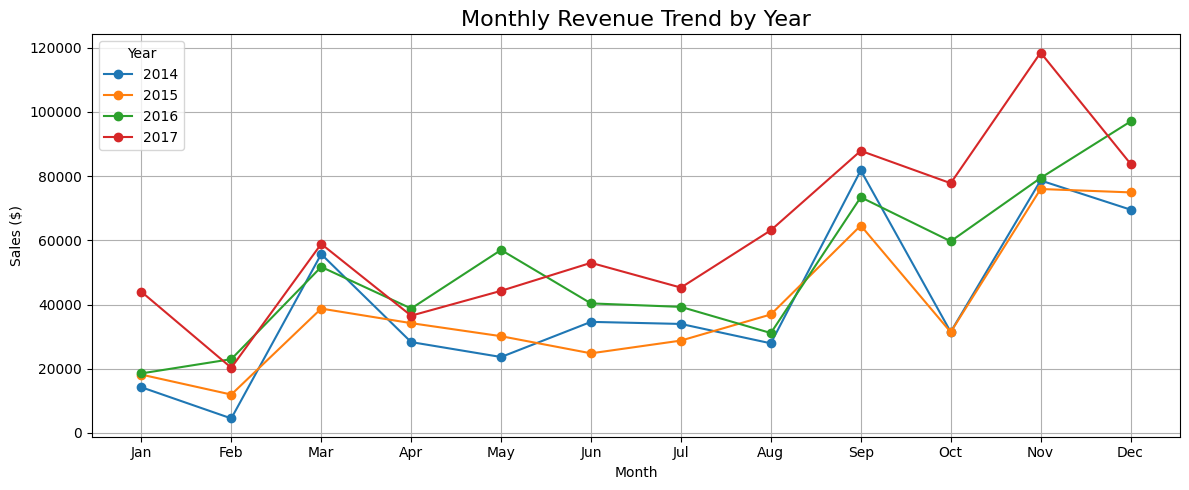

Chart 1 done! ✅


In [ ]:
# Monthly Revenue Trend
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
for year in monthly_sales['Year'].unique():
    data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(data['Month'], data['Sales'], marker='o', label=str(year))

plt.title('Monthly Revenue Trend by Year', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend(title='Year')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()
print("Chart 1 done! ✅")

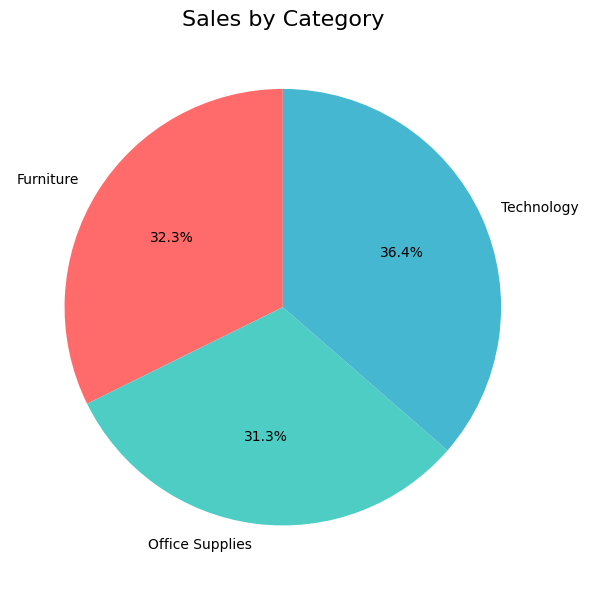

Chart 2 done! ✅


In [ ]:
# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 6))
plt.pie(category_sales['Sales'],
        labels=category_sales['Category'],
        autopct='%1.1f%%',
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
        startangle=90)

plt.title('Sales by Category', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 2 done! ✅")

/tmp/ipykernel_7599/3069279079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


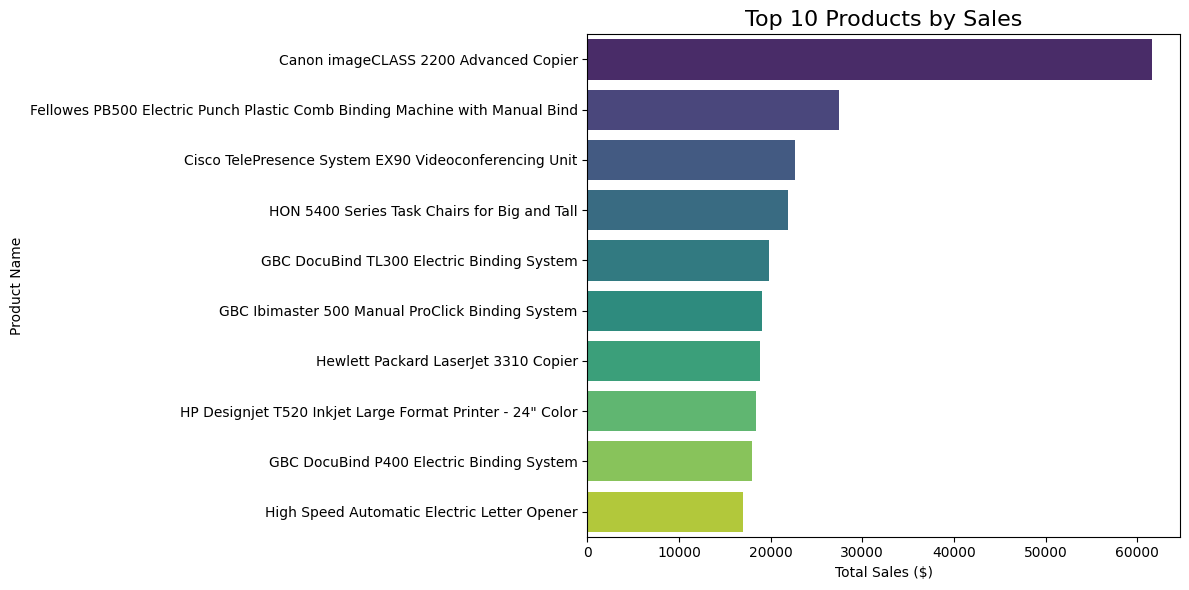

Chart 3 done! ✅


In [ ]:
# Top 10 Products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')

plt.title('Top 10 Products by Sales', fontsize=16)
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()
print("Chart 3 done! ✅")

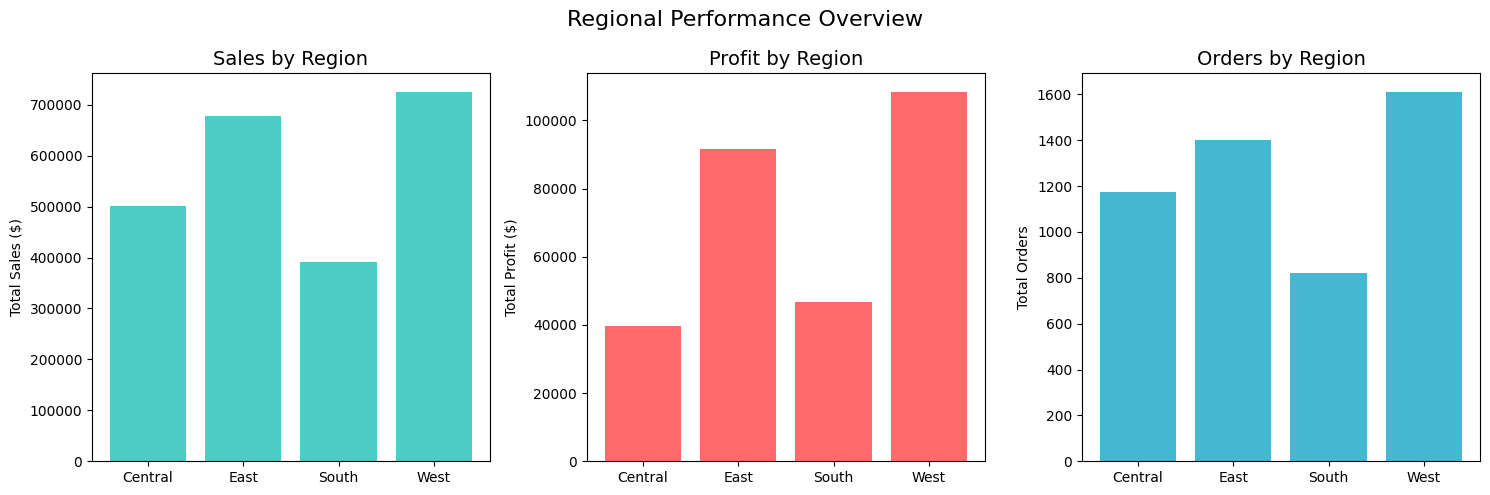

Chart 4 done! ✅


In [ ]:
# Regional Performance
region_perf = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sales by Region
axes[0].bar(region_perf['Region'], region_perf['Total_Sales'], color='#4ECDC4')
axes[0].set_title('Sales by Region', fontsize=14)
axes[0].set_ylabel('Total Sales ($)')

# Profit by Region
axes[1].bar(region_perf['Region'], region_perf['Total_Profit'], color='#FF6B6B')
axes[1].set_title('Profit by Region', fontsize=14)
axes[1].set_ylabel('Total Profit ($)')

# Orders by Region
axes[2].bar(region_perf['Region'], region_perf['Total_Orders'], color='#45B7D1')
axes[2].set_title('Orders by Region', fontsize=14)
axes[2].set_ylabel('Total Orders')

plt.suptitle('Regional Performance Overview', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 4 done! ✅")

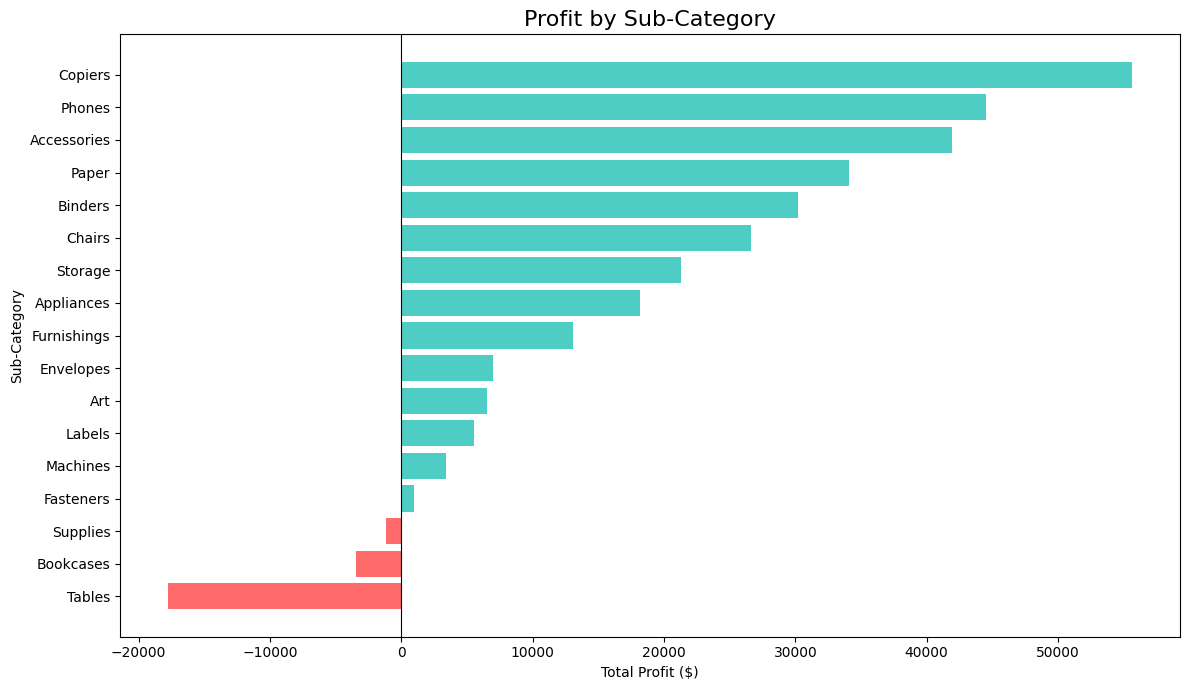

Chart 5 done! ✅


In [ ]:
# Profit by Sub-Category
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors = ['#FF6B6B' if x < 0 else '#4ECDC4' for x in sub_profit.values]

plt.figure(figsize=(12, 7))
plt.barh(sub_profit.index, sub_profit.values, color=colors)
plt.title('Profit by Sub-Category', fontsize=16)
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print("Chart 5 done! ✅")

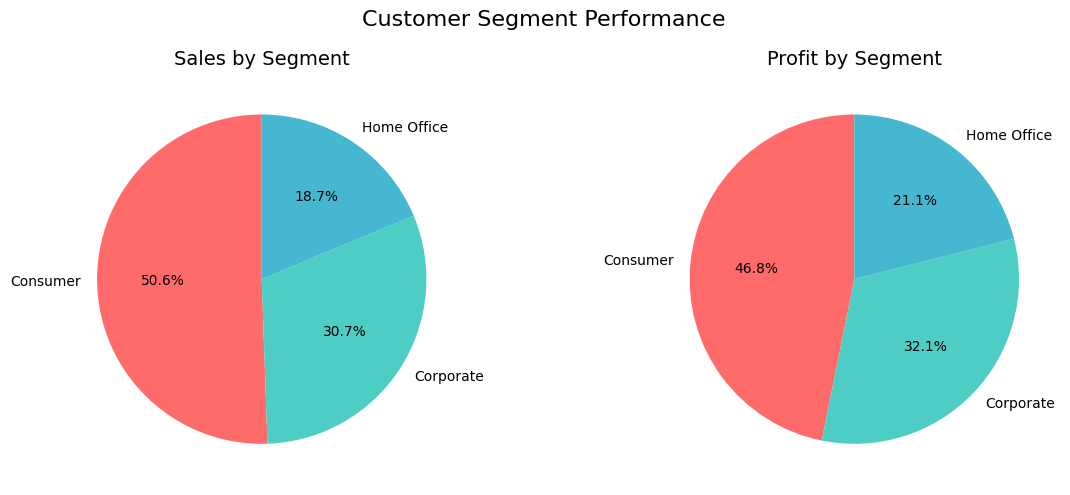

Chart 6 done! ✅


In [ ]:
# Sales by Segment
segment_perf = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sales by Segment
axes[0].pie(segment_perf['Total_Sales'],
            labels=segment_perf['Segment'],
            autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
            startangle=90)
axes[0].set_title('Sales by Segment', fontsize=14)

# Profit by Segment
axes[1].pie(segment_perf['Total_Profit'],
            labels=segment_perf['Segment'],
            autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
            startangle=90)
axes[1].set_title('Profit by Segment', fontsize=14)

plt.suptitle('Customer Segment Performance', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 6 done! ✅")

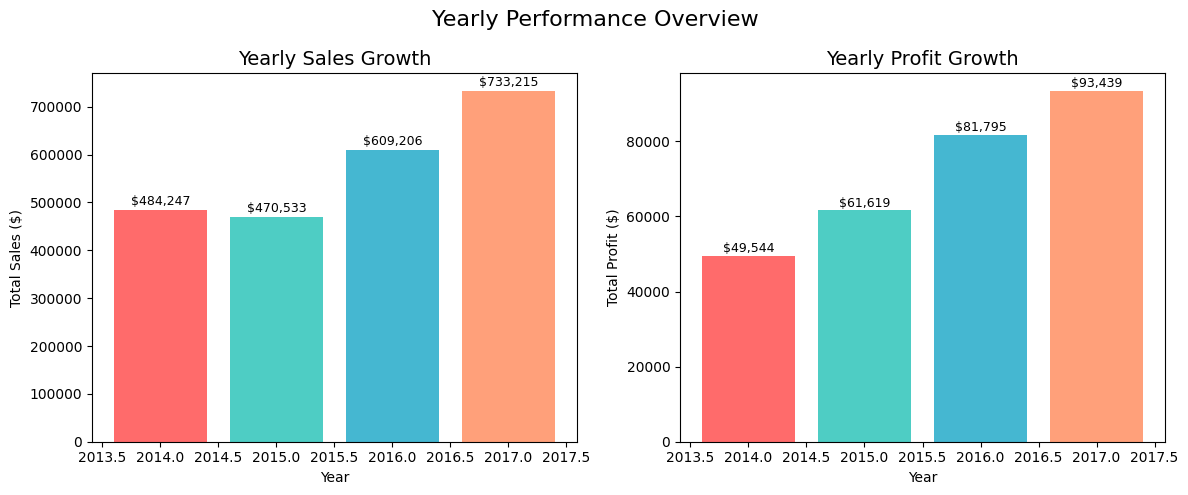

Chart 7 done! ✅


In [ ]:
# Yearly Sales Growth
yearly_sales = df.groupby('Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Yearly Sales
axes[0].bar(yearly_sales['Year'], yearly_sales['Total_Sales'],
            color=['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A'])
axes[0].set_title('Yearly Sales Growth', fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sales ($)')
for i, v in enumerate(yearly_sales['Total_Sales']):
    axes[0].text(yearly_sales['Year'].iloc[i], v + 10000,
                 f'${v:,.0f}', ha='center', fontsize=9)

# Yearly Profit
axes[1].bar(yearly_sales['Year'], yearly_sales['Total_Profit'],
            color=['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A'])
axes[1].set_title('Yearly Profit Growth', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Profit ($)')
for i, v in enumerate(yearly_sales['Total_Profit']):
    axes[1].text(yearly_sales['Year'].iloc[i], v + 1000,
                 f'${v:,.0f}', ha='center', fontsize=9)

plt.suptitle('Yearly Performance Overview', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 7 done! ✅")

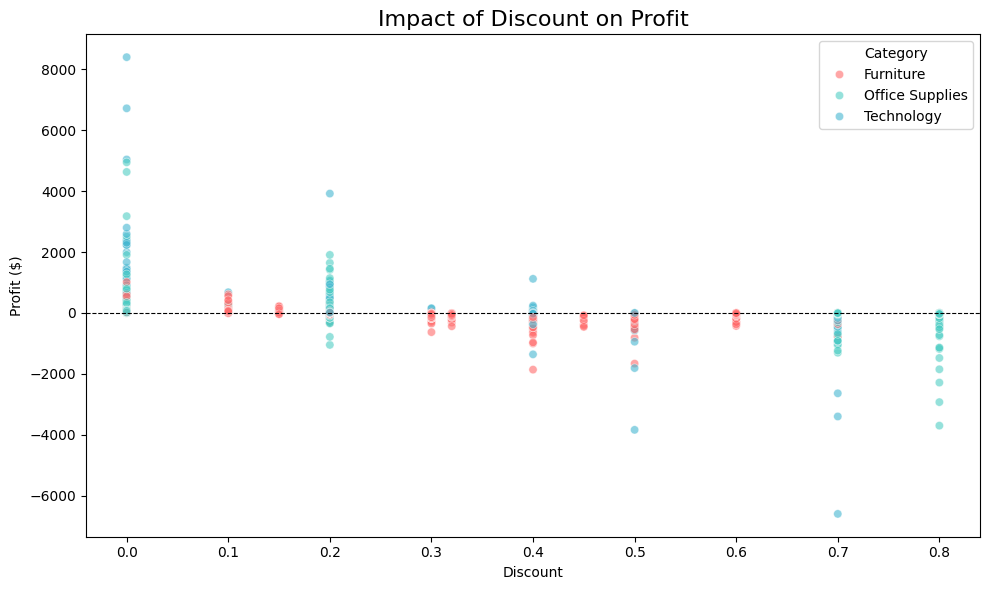

Chart 8 done! ✅


In [ ]:
# Discount vs Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit',
                hue='Category',
                palette=['#FF6B6B', '#4ECDC4', '#45B7D1'],
                alpha=0.6)

plt.title('Impact of Discount on Profit', fontsize=16)
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.legend(title='Category')
plt.tight_layout()
plt.show()
print("Chart 8 done! ✅")

In [19]:
print("=" * 50)
print("        BUSINESS INSIGHTS & FINDINGS")
print("=" * 50)

# Top Category
top_cat = df.groupby('Category')['Sales'].sum().idxmax()
print(f"\n✅ Top Category by Sales     : {top_cat}")

# Most Profitable Category
top_profit_cat = df.groupby('Category')['Profit'].sum().idxmax()
print(f"✅ Most Profitable Category  : {top_profit_cat}")

# Loss Making Sub-Category
loss_sub = df.groupby('Sub-Category')['Profit'].sum()
loss_making = loss_sub[loss_sub < 0].index.tolist()
print(f"❌ Loss Making Sub-Categories: {loss_making}")

# Best Region
best_region = df.groupby('Region')['Sales'].sum().idxmax()
print(f"\n✅ Best Region by Sales      : {best_region}")

# Worst Region
worst_region = df.groupby('Region')['Profit'].sum().idxmin()
print(f"❌ Least Profitable Region   : {worst_region}")

# Best Segment
best_segment = df.groupby('Segment')['Sales'].sum().idxmax()
print(f"\n✅ Best Customer Segment     : {best_segment}")

# Top Product
top_product = df.groupby('Product Name')['Sales'].sum().idxmax()
print(f"✅ Top Product by Sales      : {top_product}")

# Discount Impact
high_discount = df[df['Discount'] >= 0.4]['Profit'].mean()
low_discount = df[df['Discount'] < 0.2]['Profit'].mean()
print(f"\n📊 Avg Profit with High Discount : ${high_discount:.2f}")
print(f"📊 Avg Profit with Low Discount  : ${low_discount:.2f}")

print("\n" + "=" * 50)
print("Insights generated successfully! ✅")
print("=" * 50)

        BUSINESS INSIGHTS & FINDINGS

✅ Top Category by Sales     : Technology
✅ Most Profitable Category  : Technology
❌ Loss Making Sub-Categories: ['Bookcases', 'Supplies', 'Tables']

✅ Best Region by Sales      : West
❌ Least Profitable Region   : Central

✅ Best Customer Segment     : Consumer
✅ Top Product by Sales      : Canon imageCLASS 2200 Advanced Copier

📊 Avg Profit with High Discount : $-107.65
📊 Avg Profit with Low Discount  : $67.04

Insights generated successfully! ✅


In [20]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

with PdfPages('Superstore_Sales_Analysis_Report.pdf') as pdf:

    # ── Page 1: Title Page ──
    fig = plt.figure(figsize=(12, 8))
    fig.patch.set_facecolor('#2C3E50')
    plt.text(0.5, 0.65, 'Superstore Sales Analysis', ha='center',
             fontsize=30, color='white', fontweight='bold')
    plt.text(0.5, 0.50, 'Business Intelligence Report', ha='center',
             fontsize=20, color='#4ECDC4')
    plt.text(0.5, 0.35, 'Total Revenue: $2,297,200.86', ha='center',
             fontsize=16, color='white')
    plt.text(0.5, 0.25, 'Total Profit: $286,397.02  |  Orders: 5009', ha='center',
             fontsize=14, color='white')
    plt.text(0.5, 0.15, 'Prepared by: Your Name', ha='center',
             fontsize=12, color='#BDC3C7')
    plt.axis('off')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Page 2: Monthly Revenue Trend ──
    fig, ax = plt.subplots(figsize=(12, 6))
    monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
    for year in monthly_sales['Year'].unique():
        data = monthly_sales[monthly_sales['Year'] == year]
        ax.plot(data['Month'], data['Sales'], marker='o', label=str(year))
    ax.set_title('Monthly Revenue Trend by Year', fontsize=16)
    ax.set_xlabel('Month')
    ax.set_ylabel('Sales ($)')
    ax.legend(title='Year')
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
    ax.grid(True)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Page 3: Sales by Category ──
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    category_sales = df.groupby('Category')['Sales'].sum().reset_index()
    axes[0].pie(category_sales['Sales'], labels=category_sales['Category'],
                autopct='%1.1f%%', colors=['#FF6B6B','#4ECDC4','#45B7D1'])
    axes[0].set_title('Sales by Category', fontsize=14)
    category_profit = df.groupby('Category')['Profit'].sum().reset_index()
    axes[1].pie(category_profit['Profit'], labels=category_profit['Category'],
                autopct='%1.1f%%', colors=['#FF6B6B','#4ECDC4','#45B7D1'])
    axes[1].set_title('Profit by Category', fontsize=14)
    plt.suptitle('Category Performance', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Page 4: Top 10 Products ──
    fig, ax = plt.subplots(figsize=(12, 7))
    top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=top_products.values, y=top_products.index, palette='viridis', ax=ax)
    ax.set_title('Top 10 Products by Sales', fontsize=16)
    ax.set_xlabel('Total Sales ($)')
    ax.set_ylabel('Product Name')
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Page 5: Regional Performance ──
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    region_perf = df.groupby('Region').agg(
        Total_Sales=('Sales','sum'),
        Total_Profit=('Profit','sum'),
        Total_Orders=('Order ID','nunique')).reset_index()
    axes[0].bar(region_perf['Region'], region_perf['Total_Sales'], color='#4ECDC4')
    axes[0].set_title('Sales by Region', fontsize=14)
    axes[1].bar(region_perf['Region'], region_perf['Total_Profit'], color='#FF6B6B')
    axes[1].set_title('Profit by Region', fontsize=14)
    axes[2].bar(region_perf['Region'], region_perf['Total_Orders'], color='#45B7D1')
    axes[2].set_title('Orders by Region', fontsize=14)
    plt.suptitle('Regional Performance Overview', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Page 6: Profit by Sub-Category ──
    fig, ax = plt.subplots(figsize=(12, 7))
    sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
    colors = ['#FF6B6B' if x < 0 else '#4ECDC4' for x in sub_profit.values]
    ax.barh(sub_profit.index, sub_profit.values, color=colors)
    ax.set_title('Profit by Sub-Category', fontsize=16)
    ax.set_xlabel('Total Profit ($)')
    ax.axvline(x=0, color='black', linewidth=0.8)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Page 7: Yearly Growth ──
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    yearly_sales = df.groupby('Year').agg(
        Total_Sales=('Sales','sum'),
        Total_Profit=('Profit','sum')).reset_index()
    axes[0].bar(yearly_sales['Year'], yearly_sales['Total_Sales'],
                color=['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A'])
    axes[0].set_title('Yearly Sales Growth', fontsize=14)
    axes[1].bar(yearly_sales['Year'], yearly_sales['Total_Profit'],
                color=['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A'])
    axes[1].set_title('Yearly Profit Growth', fontsize=14)
    plt.suptitle('Yearly Performance Overview', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Page 8: Recommendations ──
    fig = plt.figure(figsize=(12, 8))
    fig.patch.set_facecolor('#2C3E50')
    plt.text(0.5, 0.92, 'Key Insights & Recommendations', ha='center',
             fontsize=22, color='white', fontweight='bold')
    insights = [
        "✅ Technology is the top revenue & profit generating category",
        "✅ West region leads in total sales performance",
        "✅ Consumer segment contributes highest sales among all segments",
        "❌ Tables & Bookcases sub-categories are making losses",
        "❌ High discounts (>40%) are leading to negative profits",
        "📈 Sales show consistent growth from 2014 to 2017",
        "🎯 Reduce discounts on Furniture to improve margins",
        "🎯 Focus marketing efforts on Technology products",
        "🎯 Investigate loss-making sub-categories immediately",
        "🎯 Expand operations in West region for higher returns"
    ]
    for i, insight in enumerate(insights):
        plt.text(0.1, 0.80 - i*0.08, insight, fontsize=13, color='white')
    plt.axis('off')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

print("PDF Report generated successfully! ✅")

/tmp/ipykernel_7599/1236587630.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis', ax=ax)


PDF Report generated successfully! ✅


/tmp/ipykernel_7599/1236587630.py:132: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  pdf.savefig(fig, bbox_inches='tight')
/tmp/ipykernel_7599/1236587630.py:132: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  pdf.savefig(fig, bbox_inches='tight')
/tmp/ipykernel_7599/1236587630.py:132: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  pdf.savefig(fig, bbox_inches='tight')
/tmp/ipykernel_7599/1236587630.py:132: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  pdf.savefig(fig, bbox_inches='tight')


In [21]:
from google.colab import files
files.download('Superstore_Sales_Analysis_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>